### **Libraries and Datasets**

Way to download required packages using `pip`:

In [1]:
# %pip install -U numpy
# %pip install -U pandas
# %pip install catboost
# %pip install sklearn
# %pip install optuna
# %pip install matplotlib seaborn
# %pip install lightgbm

Import of necessary libraries:

In [2]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, cross_val_score
import optuna
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Datasets uploading:

In [3]:
train_data = pd.read_csv('train_contest.csv')
train_data.head()

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0


In [4]:
test_data = pd.read_csv('for_prediction.csv')
test_data.head()

,Id,premium,name,department,has_test,response_letter_required,area,type,address,response_url,...,working_days,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url
0,0,False,Помощник маркетолога,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","[{'id': '3.206', 'name': 'Печатная реклама', '...",Москва,NaN
1,1,False,Менеджер по персоналу,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Новочер...",NaN,...,[],[],[],False,<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Санкт-Петербург,NaN
2,2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",NaN,False,False,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Уфа', 'street': 'Рубежная улица', 'b...",NaN,...,[],[],[],False,"<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'noExperience', 'name': 'Нет опыта'}",[],"[{'id': '24.378', 'name': 'Тренерский состав',...",Республика Башкортостан,NaN
3,3,False,Программист Delphi,NaN,False,False,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>Компания AMS Software - разработчик популяр...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","[{'id': '1.221', 'name': 'Программирование, Ра...",Новосибирская область,NaN
4,4,False,Ведущий специалист ВКС,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Чистопрудный бул...",NaN,...,[],[],[],False,<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","[{'id': '1.172', 'name': 'Начальный уровень, М...",Москва,NaN


Some preparations of datasets before feature engineering:

In [5]:
train_data.columns

Index(['premium', 'name', 'department', 'has_test', 'response_letter_required',
       'area', 'type', 'address', 'response_url', 'sort_point_distance',
       'published_at', 'created_at', 'archived', 'insider_interview', 'url',
       'alternate_url', 'relations', 'employer', 'snippet', 'contacts',
       'schedule', 'working_days', 'working_time_intervals',
       'working_time_modes', 'accept_temporary', 'description', 'experience',
       'key_skills', 'specializations', 'region', 'immediate_redirect_url',
       'mean_salary'],
      dtype='object')

In [6]:
train_data['premium']

0        False
1        False
2        False
3        False
4        False
         ...  
30067    False
30068    False
30069    False
30070    False
30071    False
Name: premium, Length: 30072, dtype: bool

In [7]:
features = ['name', 'region', 'employer', 'description', 'schedule', 'key_skills', 'experience', 'specializations']
X_train = train_data[features]  # start features
y_train = train_data['mean_salary']  # target variable

In [8]:
X_train.head()

,name,region,employer,description,schedule,key_skills,experience,specializations
0,Агент по недвижимости,Санкт-Петербург,"{'id': '541016', 'name': 'АРИН', 'url': 'https...","<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '20.20', 'name': 'Агент', 'profarea_id..."
1,IT-специалист/ техник,Иркутская область,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...",<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.221', 'name': 'Программирование, Ра..."
3,Эксперт / методист приемной комиссии,Москва,"{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...",<p>Департамент информационных технологий РХТУ ...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.150', 'name': 'Менеджмент продукта ..."
4,Табельщица/табельщик,Саратовская область,"{'id': '617150', 'name': 'Сигнал, группа компа...",<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '18.142', 'name': 'Машиностроение', 'p..."


In [9]:
X_test = test_data[features]
X_test.head()

,name,region,employer,description,schedule,key_skills,experience,specializations
0,Помощник маркетолога,Москва,"{'id': '2710310', 'name': 'EKO BIKE', 'url': '...",<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.206', 'name': 'Печатная реклама', '..."
1,Менеджер по персоналу,Санкт-Петербург,"{'id': '52824', 'name': 'Ваш дом, агентство не...",<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '6.254', 'name': 'Рекрутмент', 'profar..."
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'id': '230048', 'name': 'Мегаполис', 'url': '...","<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'fullDay', 'name': 'Полный день'}",[],"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '24.378', 'name': 'Тренерский состав',..."
3,Программист Delphi,Новосибирская область,"{'id': '634253', 'name': 'AMS Software', 'url'...",<p>Компания AMS Software - разработчик популяр...,"{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'id': '1.221', 'name': 'Программирование, Ра..."
4,Ведущий специалист ВКС,Москва,"{'id': '36889', 'name': 'Технокад', 'url': 'ht...",<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."


### **EDA**

In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30072 entries, 0 to 30071
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             30072 non-null  object
 1   region           30072 non-null  object
 2   employer         30072 non-null  object
 3   description      30072 non-null  object
 4   schedule         30072 non-null  object
 5   key_skills       30072 non-null  object
 6   experience       30072 non-null  object
 7   specializations  30072 non-null  object
dtypes: object(8)
memory usage: 1.8+ MB


In [11]:
X_train.describe()

,name,region,employer,description,schedule,key_skills,experience,specializations
count,30072,30072,30072,30072,30072,30072,30072,30072
unique,13521,82,13146,25707,5,20884,4,633
top,Системный администратор,Москва,"{'id': '1740', 'name': 'Яндекс', 'url': 'https...","<p>Яндексу важно, чтобы на любой вопрос, касаю...","{'id': 'fullDay', 'name': 'Полный день'}",[],"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.221', 'name': 'Программирование, Ра..."
freq,926,6236,1193,116,22711,5206,14758,5669


In [12]:
y_train.describe()

count    3.007200e+04
mean     9.772825e+04
std      1.046010e+05
min      2.000000e+01
25%      4.250000e+04
50%      7.000000e+04
75%      1.200000e+05
max      2.750000e+06
Name: mean_salary, dtype: float64

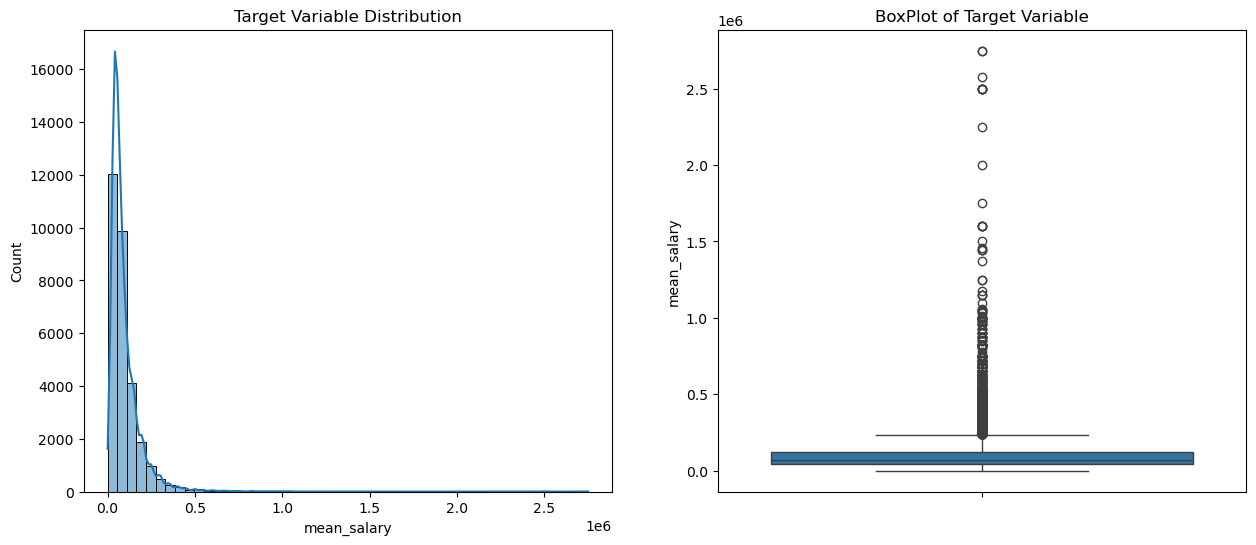

In [13]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.boxplot(y_train)
plt.title('BoxPlot of Target Variable')

plt.show()

In [14]:
y_train = y_train.to_frame()

In [15]:
y_train['log_mean_salary'] = np.log1p(y_train['mean_salary'])

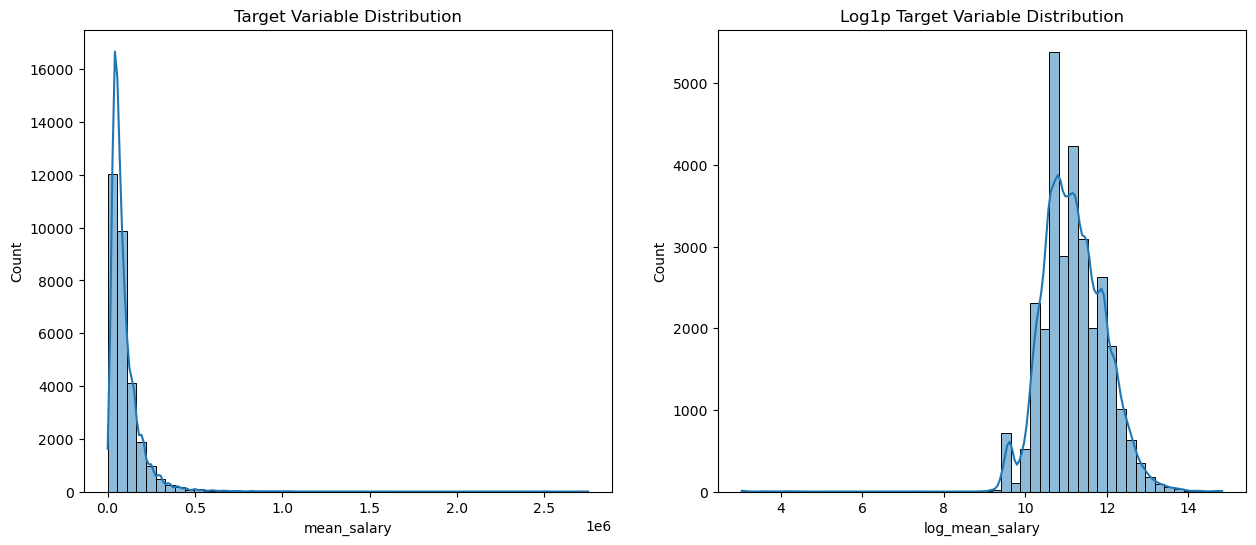

In [16]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.histplot(y_train['log_mean_salary'], bins=50, kde=True)
plt.title('Log1p Target Variable Distribution')

plt.show()

In [17]:
scaler = RobustScaler()
y_train['log_mean_salary_scaled'] = scaler.fit_transform(y_train[['log_mean_salary']])

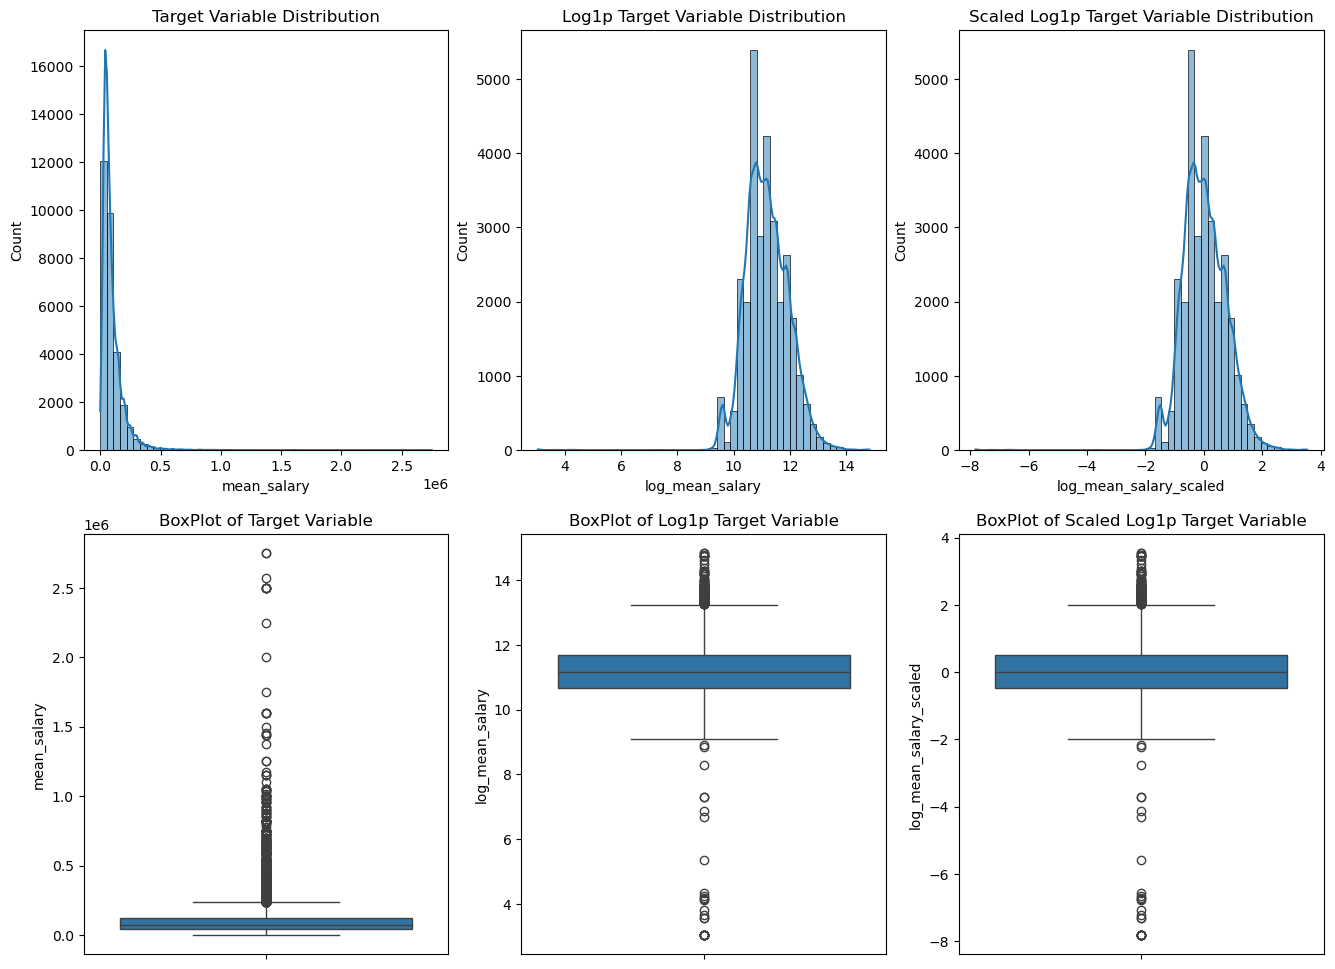

In [18]:
plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 3, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(2, 3, 2)
sns.histplot(y_train['log_mean_salary'], bins=50, kde=True)
plt.title('Log1p Target Variable Distribution')

ax5 = plt.subplot(2, 3, 3)
sns.histplot(y_train['log_mean_salary_scaled'], bins=50, kde=True)
plt.title('Scaled Log1p Target Variable Distribution')

ax1 = plt.subplot(2, 3, 4)
sns.boxplot(y_train['mean_salary'])
plt.title('BoxPlot of Target Variable')

ax2 = plt.subplot(2, 3, 5)
sns.boxplot(y_train['log_mean_salary'])
plt.title('BoxPlot of Log1p Target Variable')

ax5 = plt.subplot(2, 3, 6)
sns.boxplot(y_train['log_mean_salary_scaled'])
plt.title('BoxPlot of Scaled Log1p Target Variable')

plt.show()

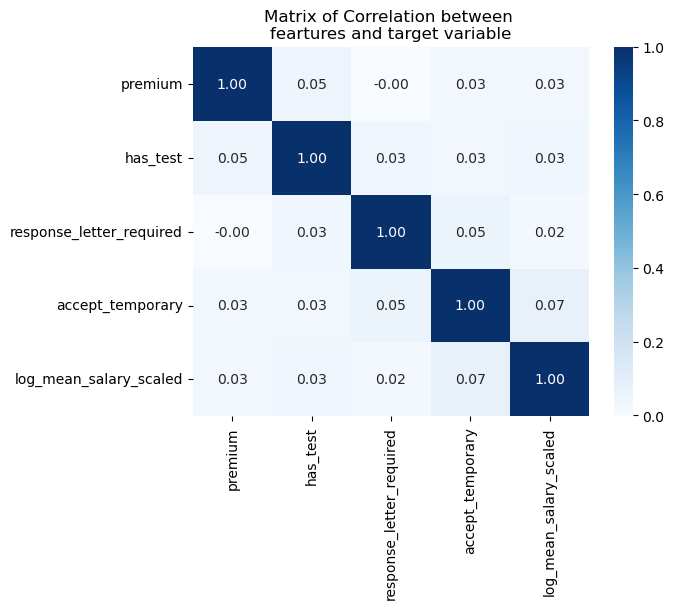

In [19]:
features_corr = pd.concat([train_data[['premium', 'has_test', 'response_letter_required', 'accept_temporary', ]], y_train['log_mean_salary_scaled']], axis=1)
correlation = features_corr.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nfeartures and target variable')
plt.show()

### **Feature Engineering**

Some ideas and functional realization of feature engineering:

In [20]:
import ast

def str_to_dict(s):
    return ast.literal_eval(s)

In [21]:
len_train, len_test = X_train.shape[0], X_test.shape[0]
print(f'Num of rows in train: {len_train} \nNum of rows in test: {len_test}')

Num of rows in train: 30072 
Num of rows in test: 7518


In [22]:
for df in [X_train, X_test]:
    df['experience_ages'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['experience_ages'][i] = str_to_dict(df['experience'][i])['id']

In [23]:
for df in [X_train, X_test]:
    df['description_len'] = df['description'].apply(lambda x: len(x) if isinstance(x, str) else 0)
    df.drop(['description'], axis=1, inplace=True)

In [24]:
for df in [X_train, X_test]:
    df['experience_ages'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['experience_ages'][i] = str_to_dict(df['experience'][i])['id']

It is decided to use `OrdinalEncoder` for better interpretation of the *experience* feature:

In [25]:
exp_categories = ['noExperience', 'between1And3', 'between3And6', 'moreThan6']
ord_encoder = OrdinalEncoder(categories=[exp_categories])
for df in [X_train, X_test]:
    df['experience_encoded'] = ord_encoder.fit_transform(df[['experience_ages']])
    df.drop(['experience', 'experience_ages'], axis=1, inplace=True)

In [26]:
X_train.head()

,name,region,employer,schedule,key_skills,specializations,description_len,experience_encoded
0,Агент по недвижимости,Санкт-Петербург,"{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",1792,0.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",2492,1.0
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",762,1.0
3,Эксперт / методист приемной комиссии,Москва,"{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",1709,1.0
4,Табельщица/табельщик,Саратовская область,"{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",533,1.0


The feature *specializations* is modified to the dictionary which format is *'professional area': 'role in the area'*. It contains the sets of roles for the set of professional areas for each row:

In [27]:
for df in [X_train, X_test]:
    n = df.shape[0]
    for i in range(n):
        df['specializations'][i] = str_to_dict(df['specializations'][i])
    df['specs'] = [None for _ in range(n)]
    for j in range(n):
        keys = set([df['specializations'][j][i]['profarea_name'] for i in range(len(df['specializations'][j]))])
        specs_dict = {}
        for k in keys:
            specs_dict[k] = set()
        for i in range(len(df['specializations'][j])):
            specs_dict[df['specializations'][j][i]['profarea_name']].add(df['specializations'][j][i]['name'])

        df['specs'][j] = specs_dict
    
    df.drop(['specializations'], axis=1, inplace=True)
    for i in range(n):
        df['specs'][i] = str(df['specs'][i])

In [28]:
X_train

,name,region,employer,schedule,key_skills,description_len,experience_encoded,specs
0,Агент по недвижимости,Санкт-Петербург,"{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",1792,0.0,"{'Строительство, недвижимость': {'Агент', 'Нач..."
1,IT-специалист/ техник,Иркутская область,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],2492,1.0,"{'Информационные технологии, интернет, телеком..."
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",762,1.0,"{'Информационные технологии, интернет, телеком..."
3,Эксперт / методист приемной комиссии,Москва,"{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1709,1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук..."
4,Табельщица/табельщик,Саратовская область,"{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",533,1.0,"{'Производство, сельское хозяйство': {'Машинос..."
...,...,...,...,...,...,...,...,...
30067,Руководитель отдела персонала,Москва,"{'id': '127256', 'name': 'СИНЕРГИЯ', 'url': 'h...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Адапт...",2068,3.0,{'Высший менеджмент': {'Другое'}}
30068,Специалист по развитию и обучению персонала,Республика Татарстан,"{'id': '1068750', 'name': 'Brinex', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Управление временем'}, {'name': 'Ор...",2301,1.0,"{'Управление персоналом, тренинги': {'Управлен..."
30069,Инженер-программист,Челябинская область,"{'id': '824486', 'name': 'Магнитогорский метал...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'SQL'}, {'name': 'Работа с базами да...",611,1.0,"{'Информационные технологии, интернет, телеком..."
30070,Куратор проекта,Свердловская область,"{'id': '1947314', 'name': 'ANCOR', 'url': 'htt...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Пользователь ПК'}, {'name': 'Работа...",1248,1.0,"{'Информационные технологии, интернет, телеком..."


In [29]:
for df in [X_train, X_test]:
    df['num_specs'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['specs'][i] = str_to_dict(df['specs'][i])
        number = 0
        for _, v in df['specs'][i].items():
            number += len(v)
        df['num_specs'][i] = number
        df['specs'][i] = str(df['specs'][i])

In [30]:
def rating(grade, knowladge, alpha, beta):
    return alpha * grade + beta * knowladge / (4 - grade)

for df in [X_train, X_test]:
    df['spec_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['spec_rating'][i] = rating(
            grade=df['experience_encoded'][i],
            knowladge=df['num_specs'][i],
            alpha=5,
            beta=4
        )

In [31]:
for df in [X_train, X_test]:
    df['key_skills_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['key_skills_rating'][i] = rating(
            grade=df['experience_encoded'][i],
            knowladge=len(str_to_dict(df['key_skills'][i])),
            alpha=4.5,
            beta=2
        )

In [32]:
for df in [X_train, X_test]:
    df.drop(['num_specs'], axis=1, inplace=True)

In [33]:
X_train.head()

,name,region,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Агент по недвижимости,Санкт-Петербург,"{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",1792,0.0,"{'Строительство, недвижимость': {'Агент', 'Нач...",5.0,3.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],2492,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,4.5
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",762,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,6.5
3,Эксперт / методист приемной комиссии,Москва,"{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1709,1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук...",7.666667,7.833333
4,Табельщица/табельщик,Саратовская область,"{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",533,1.0,"{'Производство, сельское хозяйство': {'Машинос...",6.333333,9.166667


In [34]:
X_test.head()

,name,region,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Помощник маркетолога,Москва,"{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...",894,1.0,"{'Маркетинг, реклама, PR': {'Печатная реклама'...",11.666667,7.833333
1,Менеджер по персоналу,Санкт-Петербург,"{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...",1337,0.0,"{'Управление персоналом, тренинги': {'Управлен...",4.0,3.0
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],952,0.0,"{'Спортивные клубы, фитнес, салоны красоты': {...",1.0,0.0
3,Программист Delphi,Новосибирская область,"{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...",2248,2.0,"{'Информационные технологии, интернет, телеком...",20.0,14.0
4,Ведущий специалист ВКС,Москва,"{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...",977,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,8.5


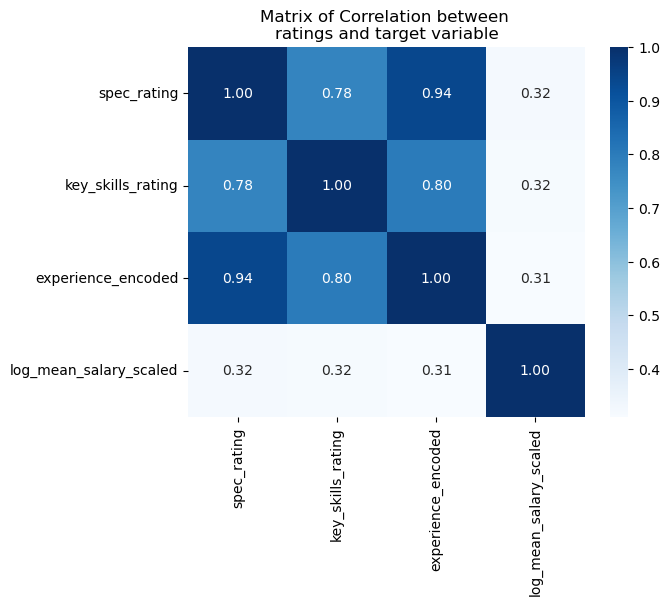

In [35]:
corr_test_df = pd.concat([X_train[['spec_rating', 'key_skills_rating', 'experience_encoded']], y_train['log_mean_salary_scaled']], axis=1)
correlation = corr_test_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nratings and target variable')
plt.show()

*to be (maybe) continued…*

### **Model Initialization and Optimization**

#### CatBoost

For fitting and predicting the `CatBoostRegressor` model (from `catboost` library) is selected. It's a good regression model, especially in categorial features processing. Build-in methods of encoding-decoding and feature transformations actually are able to work better than other methods of feature preprocessing such as scalers or encoders from Scikit-learn or other libraries.

`Optuna` Framework usage for optimal selection of CatBoost Regressor hyperparameters:

In [36]:
X_train.head()

,name,region,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Агент по недвижимости,Санкт-Петербург,"{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",1792,0.0,"{'Строительство, недвижимость': {'Агент', 'Нач...",5.0,3.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],2492,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,4.5
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",762,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,6.5
3,Эксперт / методист приемной комиссии,Москва,"{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1709,1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук...",7.666667,7.833333
4,Табельщица/табельщик,Саратовская область,"{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",533,1.0,"{'Производство, сельское хозяйство': {'Машинос...",6.333333,9.166667


In [37]:
X_test.head()

,name,region,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Помощник маркетолога,Москва,"{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...",894,1.0,"{'Маркетинг, реклама, PR': {'Печатная реклама'...",11.666667,7.833333
1,Менеджер по персоналу,Санкт-Петербург,"{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...",1337,0.0,"{'Управление персоналом, тренинги': {'Управлен...",4.0,3.0
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],952,0.0,"{'Спортивные клубы, фитнес, салоны красоты': {...",1.0,0.0
3,Программист Delphi,Новосибирская область,"{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...",2248,2.0,"{'Информационные технологии, интернет, телеком...",20.0,14.0
4,Ведущий специалист ВКС,Москва,"{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...",977,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,8.5


In [ ]:
cat_features = ['name', 'region', 'employer', 'schedule', 'key_skills', 'specs']

def objective(trial):
    global cat_features
    params = {
        'depth': trial.suggest_int('depth', 14, 16),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.027, 0.033),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 8, 9),
        'iterations': trial.suggest_int('iterations', 1300, 1500)
    }
    
    model = CatBoostRegressor(**params, loss_function='MAE', cat_features=cat_features, verbose=50)
    score = cross_val_score(model, X_train, y_train['log_mean_salary_scaled'], cv=3, scoring="neg_mean_absolute_error")
    
    return -score.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

In [ ]:
print(f'Best hyperparameters: {study.best_params}')

Best hyperparameters: {'depth': 14, 'learning_rate': 0.011390844560831734, 'l2_leaf_reg': 8, 'iterations': 1319}


In [38]:
cat_features = ['name', 'region', 'employer', 'schedule', 'key_skills', 'specs']
model = CatBoostRegressor(
    # iterations=study.best_params['iterations'],
    # learning_rate=study.best_params['learning_rate'] + 0.0012,
    # depth=study.best_params['depth'],
    # l2_leaf_reg=study.best_params['l2_leaf_reg'] + 0.54,
    iterations=1350,
    learning_rate=0.03,
    depth=14,
    l2_leaf_reg=8.5,
    loss_function='MAE',
    early_stopping_rounds=20
)

In [39]:
model.fit(X_train, y_train['log_mean_salary_scaled'], cat_features=cat_features, verbose=50)

0:	learn: 0.5668050	total: 117ms	remaining: 2m 38s
50:	learn: 0.3294443	total: 2.69s	remaining: 1m 8s
100:	learn: 0.2720826	total: 5.42s	remaining: 1m 7s
150:	learn: 0.2513233	total: 8.15s	remaining: 1m 4s
200:	learn: 0.2393066	total: 11s	remaining: 1m 2s
250:	learn: 0.2301041	total: 13.9s	remaining: 1m
300:	learn: 0.2194449	total: 16.9s	remaining: 58.9s
350:	learn: 0.2106988	total: 19.7s	remaining: 56s
400:	learn: 0.2021808	total: 22.6s	remaining: 53.5s
450:	learn: 0.1927751	total: 25.6s	remaining: 51s
500:	learn: 0.1849205	total: 28.6s	remaining: 48.5s
550:	learn: 0.1774688	total: 31.5s	remaining: 45.7s
600:	learn: 0.1711107	total: 34.6s	remaining: 43.1s
650:	learn: 0.1657451	total: 37.6s	remaining: 40.4s
700:	learn: 0.1606342	total: 40.7s	remaining: 37.7s
750:	learn: 0.1559884	total: 43.6s	remaining: 34.8s
800:	learn: 0.1517161	total: 46.4s	remaining: 31.8s
850:	learn: 0.1475675	total: 49.2s	remaining: 28.9s
900:	learn: 0.1429586	total: 52s	remaining: 25.9s
950:	learn: 0.1398367	tot

           Feature Id  Importances
0               specs    17.405749
1              region    15.968027
2            employer    12.344420
3     description_len    12.241312
4            schedule    11.453414
5                name    10.389987
6   key_skills_rating     6.446024
7         spec_rating     5.991419
8  experience_encoded     4.766881
9          key_skills     2.992768


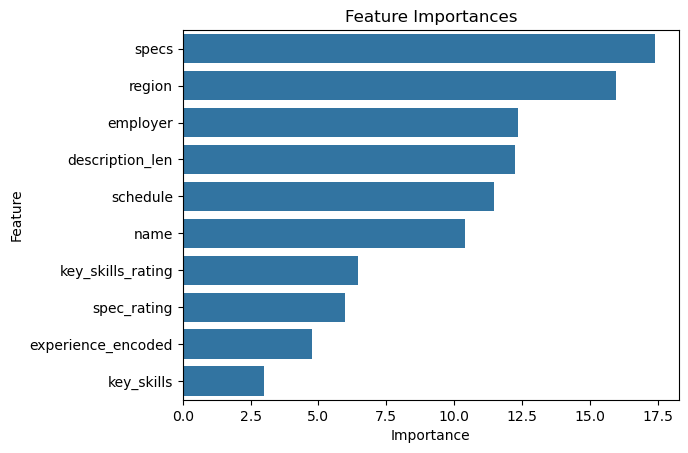

In [40]:
feature_importances = model.get_feature_importance(prettified=True)

print(feature_importances)

sns.barplot(x='Importances', y='Feature Id', data=feature_importances)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [41]:
y_hat_scaled = model.predict(X_test)
y_hat_log = scaler.inverse_transform(y_hat_scaled.reshape(-1, 1)).flatten()
y_hat = np.expm1(y_hat_log)

### **Submission Data Exporting**

In [42]:
submission_data = pd.DataFrame({'Id': range(len(y_hat)), 'Predicted': y_hat})
submission_data

,Id,Predicted
0,0,38802.044977
1,1,46291.039727
2,2,26070.326763
3,3,183232.735756
4,4,65803.633676
...,...,...
7513,7513,34275.032741
7514,7514,80069.393336
7515,7515,29523.374019
7516,7516,109725.411087


In [43]:
submission_data.to_csv("submission.csv", index=False, encoding="utf-8")